# Question 3 - Canny Edge Detection

## Environment Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

## Helper Functions From Q1

In [2]:
def manual_convolve2d(image, kernel, padding='same', strides=1):
    """
    To have different padding pass an int with the padding you want
    Default padding (same) keeps the image shape
    """
    k_h, k_w = kernel.shape
    h, w = image.shape

    if padding == 'same':
        pad_h = (k_h - 1) // 2
        pad_w = (k_w - 1) // 2
    else:
        pad_h = padding
        pad_w = padding

    padded_h = h + (2 * pad_h)
    padded_w = w + (2 * pad_w)
    padded_image = np.zeros((padded_h, padded_w))

    padded_image[pad_h : pad_h + h, pad_w : pad_w + w] = image

    out_h = (padded_h - k_h) // strides + 1
    out_w = (padded_w - k_w) // strides + 1

    output = np.zeros((out_h, out_w))

    for y in range(out_h):
        for x in range(out_w):
            start_y = y * strides
            end_y = start_y + k_h
            start_x = x * strides
            end_x = start_x + k_w

            roi = padded_image[start_y:end_y, start_x:end_x]
            k = (roi * kernel).sum()

            output[y, x] = k

    return output


def get_gaussian_kernel(size, sigma):

    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)


sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

## Load Image

Loading a grayscale image for edge detection.

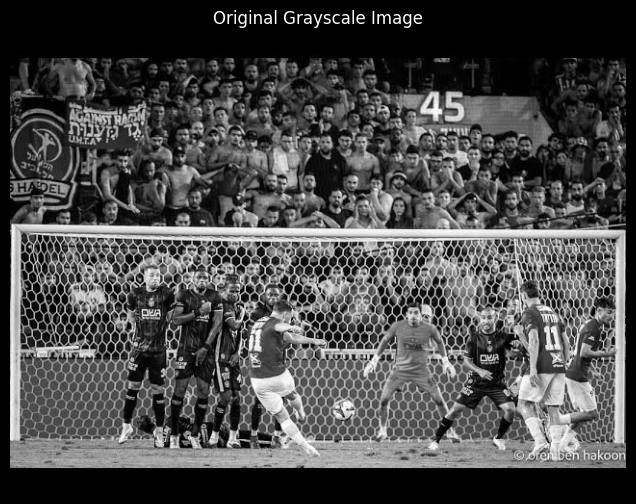

Image shape: (480, 640)
Image dtype: float64


In [3]:
image_color = cv2.imread('hapoel.jpg')
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(8, 6))
plt.imshow(image_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

print(f"Image shape: {image_gray.shape}")
print(f"Image dtype: {image_gray.dtype}")

---
## Step 1: Noise Reduction using Gaussian Blur

Apply Gaussian smoothing to reduce image noise before computing edges.

**Why noise reduction is critical for preventing false edges:**

Noise in images appears as random pixel intensity variations. When we compute gradients (which is the basis of edge detection), these small intensity changes due to noise can produce high gradient values that get mistakenly identified as edges. By applying Gaussian smoothing first:

1. **High-frequency noise is suppressed** - The Gaussian filter acts as a low-pass filter, smoothing out rapid intensity changes caused by noise
2. **True edges are preserved** - The Gaussian filter gives more weight to nearby pixels, so significant edges (which span multiple pixels) are largely maintained
3. **False positives are reduced** - Without smoothing, even slight sensor noise or image compression artifacts could trigger edge detection

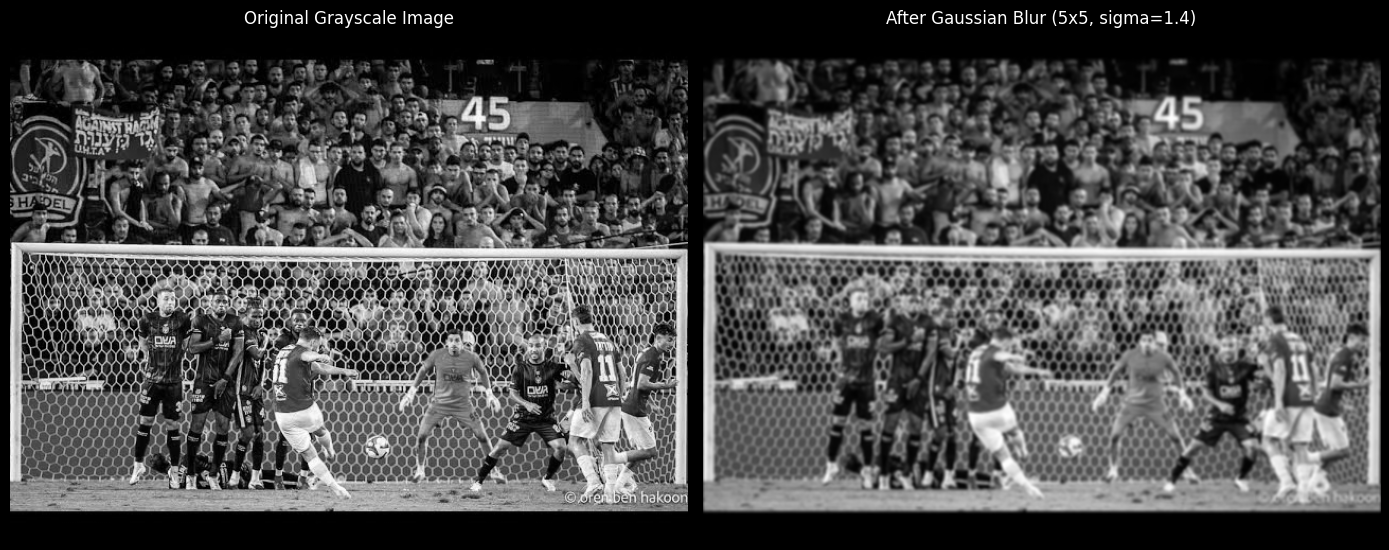

In [4]:
def apply_gaussian_blur(image, kernel_size=5, sigma=1.4):
    """
    Apply Gaussian blur to reduce noise.
    
    Parameters:
        image: grayscale image
        kernel_size: size of Gaussian kernel (3, 5, or 7)
        sigma: standard deviation of Gaussian
    
    Returns:
        Blurred image
    """
    gaussian_kernel = get_gaussian_kernel(kernel_size, sigma)
    blurred = manual_convolve2d(image, gaussian_kernel)
    return blurred


# Apply Gaussian blur with 5x5 kernel (common choice for Canny)
blurred_image = apply_gaussian_blur(image_gray, kernel_size=5, sigma=1.4)

# Display original and blurred images
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')

axes[1].imshow(blurred_image, cmap='gray')
axes[1].set_title('After Gaussian Blur (5x5, sigma=1.4)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Step 2: Gradient Computation using Sobel Operators

Compute horizontal and vertical gradients using Sobel-X and Sobel-Y kernels, then calculate gradient magnitude and orientation.

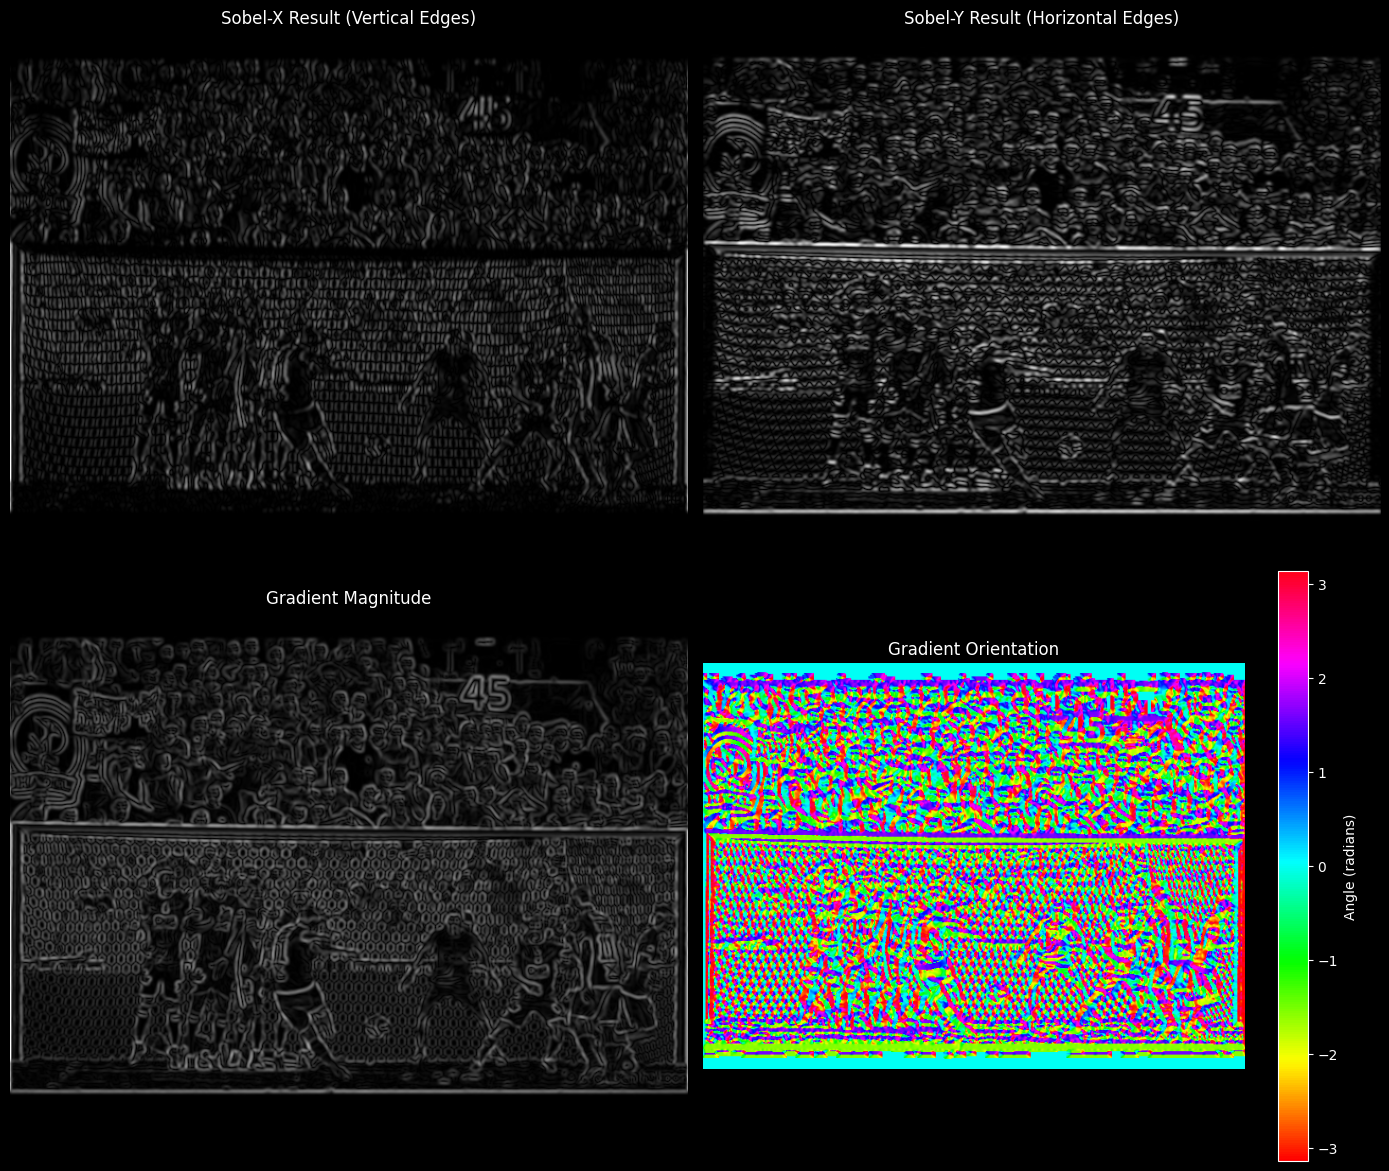

Gradient orientation ranges from -3.14 to 3.14 radians
This corresponds to approximately -180.0 to 180.0 degrees


In [5]:
def compute_gradients(image):
    """
    Compute gradient magnitude and orientation using Sobel operators.
    
    Parameters:
        image: grayscale image (preferably smoothed)
    
    Returns:
        gradient_x: horizontal gradient
        gradient_y: vertical gradient
        magnitude: gradient magnitude
        orientation: gradient direction in radians
    """
    gradient_x = manual_convolve2d(image, sobel_x)
    gradient_y = manual_convolve2d(image, sobel_y)
    
    magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    orientation = np.arctan2(gradient_y, gradient_x)
    
    return gradient_x, gradient_y, magnitude, orientation


# Compute gradients on the blurred image
grad_x, grad_y, grad_magnitude, grad_orientation = compute_gradients(blurred_image)

# Display results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(np.abs(grad_x), cmap='gray')
axes[0, 0].set_title('Sobel-X Result (Vertical Edges)')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(grad_y), cmap='gray')
axes[0, 1].set_title('Sobel-Y Result (Horizontal Edges)')
axes[0, 1].axis('off')

axes[1, 0].imshow(grad_magnitude, cmap='gray')
axes[1, 0].set_title('Gradient Magnitude')
axes[1, 0].axis('off')

im = axes[1, 1].imshow(grad_orientation, cmap='hsv')
axes[1, 1].set_title('Gradient Orientation')
axes[1, 1].axis('off')
plt.colorbar(im, ax=axes[1, 1], label='Angle (radians)')

plt.tight_layout()
plt.show()

print(f"Gradient orientation ranges from {grad_orientation.min():.2f} to {grad_orientation.max():.2f} radians")
print(f"This corresponds to approximately {np.degrees(grad_orientation.min()):.1f} to {np.degrees(grad_orientation.max()):.1f} degrees")

---
## Step 3: Non-Maximum Suppression (NMS)

Thin the edges by keeping only the local maxima along the gradient direction.

**Why NMS is essential for clean, single-pixel-wide edges:**

After gradient computation, edges appear as "thick" regions with high gradient values spanning multiple pixels. Without NMS:
- Edges would be blurry and several pixels wide
- It would be difficult to precisely locate the actual edge position
- Connected component analysis and shape detection would be inaccurate

NMS works by:
1. Quantizing gradient directions to 4 discrete angles (0, 45, 90, 135 degrees)
2. For each pixel, comparing its magnitude with the two neighboring pixels along the gradient direction
3. Keeping the pixel only if it's a local maximum (greater than both neighbors)

This produces thin, well-localized edges that accurately represent object boundaries.

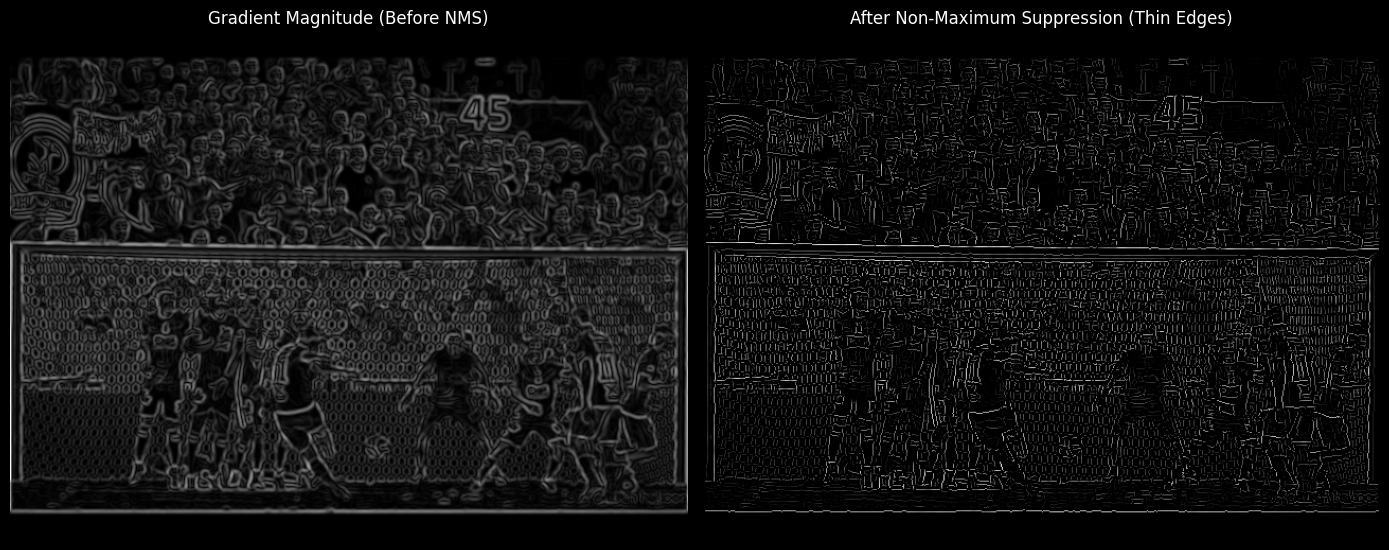

In [6]:
def non_maximum_suppression(magnitude, orientation):
    """
    Apply non-maximum suppression to thin edges.
    
    Parameters:
        magnitude: gradient magnitude image
        orientation: gradient orientation in radians
    
    Returns:
        Suppressed image with thin edges
    """
    h, w = magnitude.shape
    suppressed = np.zeros((h, w), dtype=np.float64)
    
    # Convert orientation to degrees and ensure positive values [0, 180)
    angle = np.degrees(orientation) % 180
    
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            q = 255  # neighbor 1
            r = 255  # neighbor 2
            
            # Quantize angle to 4 directions and get neighbors
            # 0 degrees: horizontal edge, compare left-right
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = magnitude[i, j + 1]
                r = magnitude[i, j - 1]
            # 45 degrees: diagonal edge (top-right to bottom-left)
            elif 22.5 <= angle[i, j] < 67.5:
                q = magnitude[i + 1, j - 1]
                r = magnitude[i - 1, j + 1]
            # 90 degrees: vertical edge, compare top-bottom
            elif 67.5 <= angle[i, j] < 112.5:
                q = magnitude[i + 1, j]
                r = magnitude[i - 1, j]
            # 135 degrees: diagonal edge (top-left to bottom-right)
            elif 112.5 <= angle[i, j] < 157.5:
                q = magnitude[i - 1, j - 1]
                r = magnitude[i + 1, j + 1]
            
            # Keep pixel if it's a local maximum
            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                suppressed[i, j] = magnitude[i, j]
            else:
                suppressed[i, j] = 0
    
    return suppressed


# Apply NMS
nms_result = non_maximum_suppression(grad_magnitude, grad_orientation)

# Display NMS result
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(grad_magnitude, cmap='gray')
axes[0].set_title('Gradient Magnitude (Before NMS)')
axes[0].axis('off')

axes[1].imshow(nms_result, cmap='gray')
axes[1].set_title('After Non-Maximum Suppression (Thin Edges)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Step 4: Double Thresholding

**Why double thresholding helps remove noise and false positives:**

Single thresholding has a fundamental problem:
- If threshold is too high: We miss true edges with lower gradient values (fragmented edges)
- If threshold is too low: We include too much noise (false positives)

Double thresholding solves this by:
1. Using a high threshold to identify definite edges (strong edges)
2. Using a low threshold to identify candidate edges (weak edges)
3. In the next step (hysteresis), weak edges connected to strong edges are kept, while isolated weak edges (likely noise) are removed

This approach provides a good balance between detecting all true edges and rejecting noise.

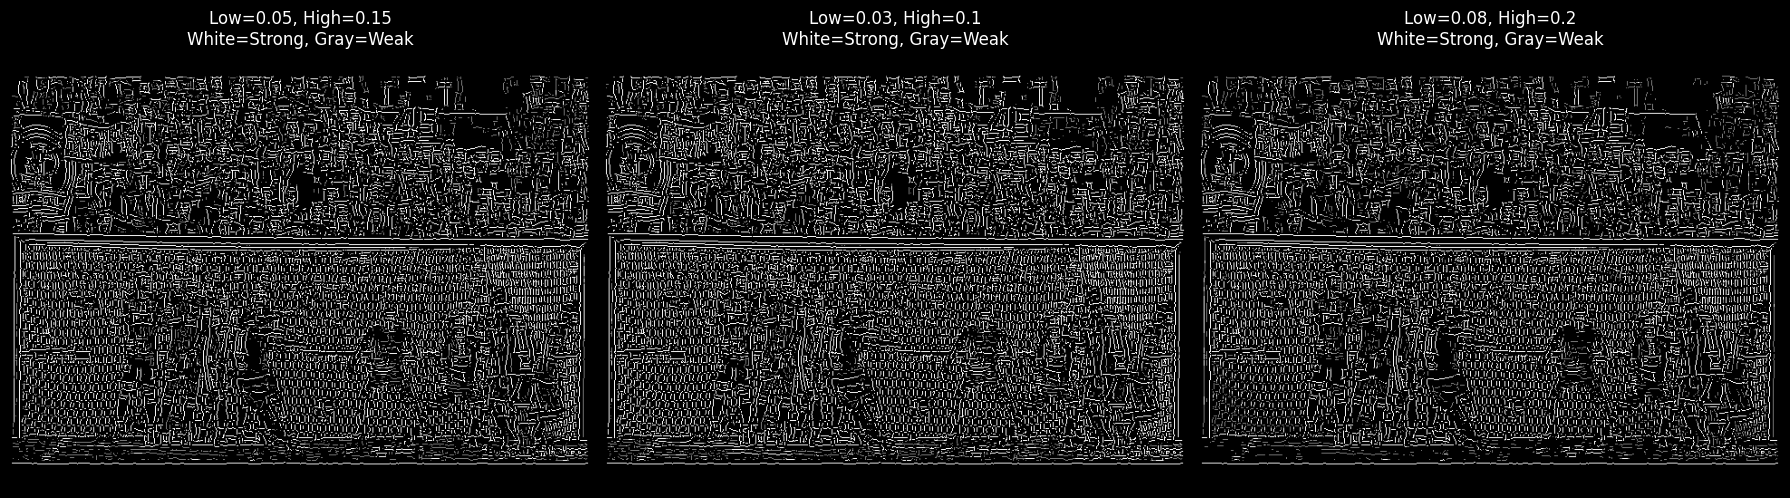

Strong edge value: 255
Weak edge value: 50


In [7]:
def double_threshold(image, low_ratio=0.05, high_ratio=0.15):
    """
    Apply double thresholding to classify edges.
    
    Parameters:
        image: NMS result image
        low_ratio: low threshold as ratio of max value
        high_ratio: high threshold as ratio of max value
    
    Returns:
        thresholded: image with strong=255, weak=50, non-edge=0
        strong_value: value used for strong edges
        weak_value: value used for weak edges
    """
    high_threshold = image.max() * high_ratio
    low_threshold = image.max() * low_ratio
    
    h, w = image.shape
    thresholded = np.zeros((h, w), dtype=np.float64)
    
    strong_value = 255
    weak_value = 50
    
    # Strong edges: above high threshold
    strong_i, strong_j = np.where(image >= high_threshold)
    
    # Weak edges: between thresholds
    weak_i, weak_j = np.where((image < high_threshold) & (image >= low_threshold))
    
    thresholded[strong_i, strong_j] = strong_value
    thresholded[weak_i, weak_j] = weak_value
    
    return thresholded, strong_value, weak_value


# Apply double thresholding with different values to compare
threshold_configs = [
    (0.05, 0.15),  # Default
    (0.03, 0.10),  # Lower thresholds (more edges)
    (0.08, 0.20),  # Higher thresholds (fewer edges)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (low_r, high_r) in enumerate(threshold_configs):
    thresh_result, strong_val, weak_val = double_threshold(nms_result, low_r, high_r)
    
    # Create colored visualization
    vis = np.zeros((*thresh_result.shape, 3), dtype=np.uint8)
    vis[thresh_result == strong_val] = [255, 255, 255]  # Strong = white
    vis[thresh_result == weak_val] = [128, 128, 128]    # Weak = gray
    
    axes[idx].imshow(vis)
    axes[idx].set_title(f'Low={low_r}, High={high_r}\nWhite=Strong, Gray=Weak')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Use default thresholds for next step
thresholded_result, STRONG, WEAK = double_threshold(nms_result, 0.05, 0.15)
print(f"Strong edge value: {STRONG}")
print(f"Weak edge value: {WEAK}")

---
## Step 5: Edge Tracking by Hysteresis

**How hysteresis prevents fragmentation of edges and removes noise:**

Edge fragmentation occurs when parts of a continuous edge have gradient values below the threshold, creating gaps. Hysteresis addresses this by:

1. **Starting from strong edges**: These are definitely part of real edges
2. **Following connected weak edges**: Weak edges adjacent to strong edges (or to weak edges already confirmed as edges) are promoted to strong edges
3. **Using 8-connectivity**: Checking all 8 neighbors ensures diagonal edges are properly connected

This approach:
- **Preserves continuity**: Weak pixels that are part of a true edge (connected to strong pixels) are kept
- **Removes noise**: Isolated weak pixels (not connected to any strong edge) are removed, as they're likely noise
- **Produces clean binary edges**: The final output has only confirmed edges

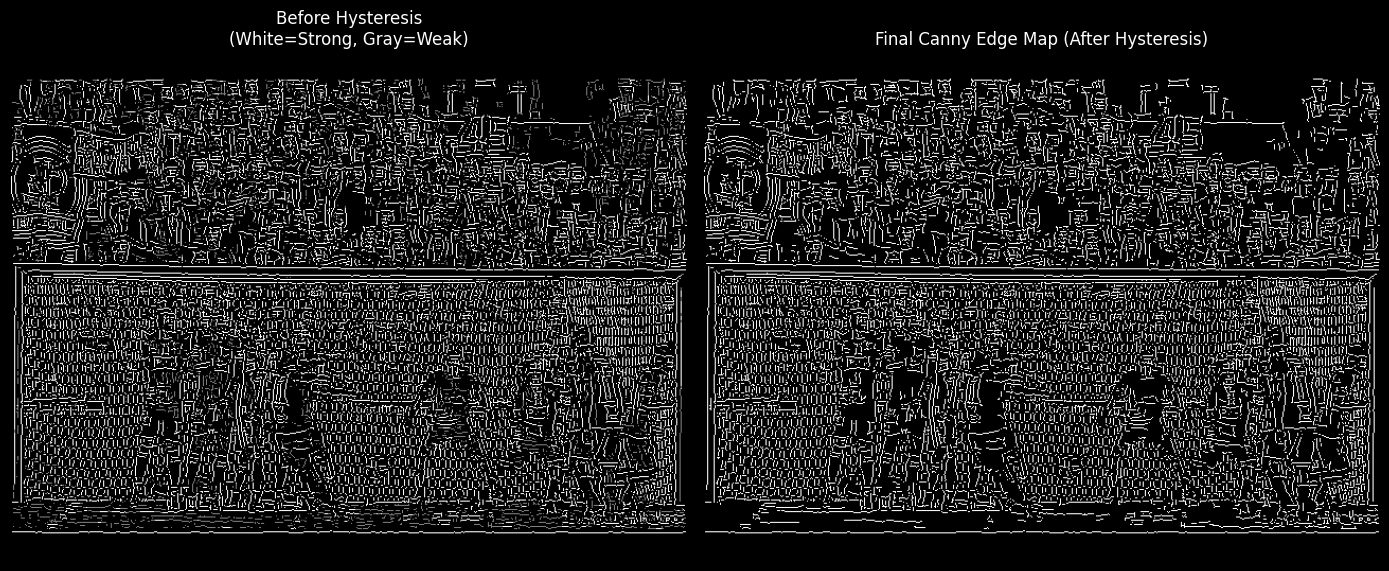

In [8]:
def hysteresis_tracking(image, strong_value, weak_value):
    """
    Apply edge tracking by hysteresis using BFS.
    
    Parameters:
        image: double-thresholded image
        strong_value: value representing strong edges
        weak_value: value representing weak edges
    
    Returns:
        Binary edge map
    """
    h, w = image.shape
    result = np.zeros((h, w), dtype=np.uint8)
    
    # Find all strong edge pixels
    strong_i, strong_j = np.where(image == strong_value)
    
    # Mark all strong edges in result
    result[strong_i, strong_j] = 255
    
    # 8-connectivity neighbors
    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 (0, -1),           (0, 1),
                 (1, -1),  (1, 0),  (1, 1)]
    
    # BFS from each strong edge to find connected weak edges
    queue = deque(zip(strong_i, strong_j))
    visited = set(zip(strong_i, strong_j))
    
    while queue:
        y, x = queue.popleft()
        
        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            
            # Check bounds
            if 0 <= ny < h and 0 <= nx < w:
                # If it's a weak edge and not visited
                if (ny, nx) not in visited and image[ny, nx] == weak_value:
                    result[ny, nx] = 255  # Promote to strong edge
                    visited.add((ny, nx))
                    queue.append((ny, nx))
    
    return result


# Apply hysteresis
final_edges = hysteresis_tracking(thresholded_result, STRONG, WEAK)

# Display the final Canny edge map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create colored visualization for thresholded
thresh_vis = np.zeros((*thresholded_result.shape, 3), dtype=np.uint8)
thresh_vis[thresholded_result == STRONG] = [255, 255, 255]
thresh_vis[thresholded_result == WEAK] = [128, 128, 128]

axes[0].imshow(thresh_vis)
axes[0].set_title('Before Hysteresis\n(White=Strong, Gray=Weak)')
axes[0].axis('off')

axes[1].imshow(final_edges, cmap='gray')
axes[1].set_title('Final Canny Edge Map (After Hysteresis)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Step 6: Comparison with OpenCV's cv2.Canny

Compare our manual implementation with OpenCV's built-in Canny edge detector.

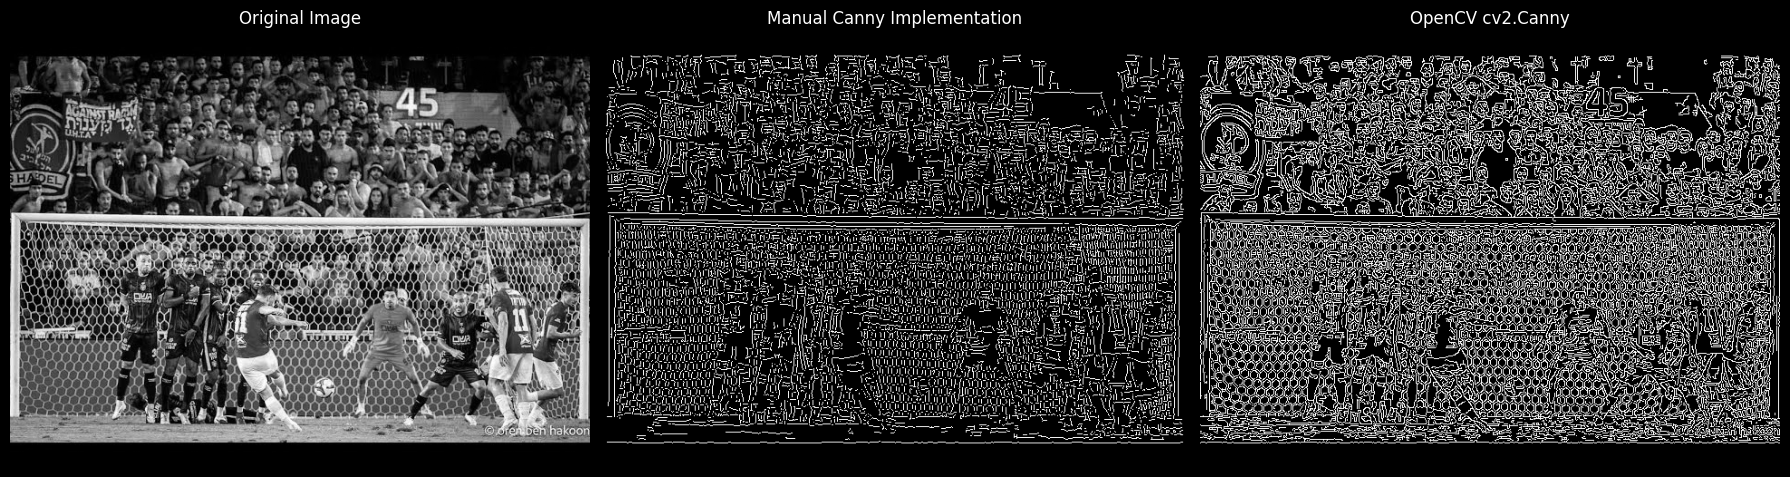

In [9]:
# Create a complete Canny edge detection function
def manual_canny(image, gaussian_size=5, gaussian_sigma=1.4, low_ratio=0.05, high_ratio=0.15):
    """
    Complete manual Canny edge detection pipeline.
    
    Parameters:
        image: grayscale input image
        gaussian_size: size of Gaussian kernel for smoothing
        gaussian_sigma: standard deviation for Gaussian
        low_ratio: low threshold ratio for double thresholding
        high_ratio: high threshold ratio for double thresholding
    
    Returns:
        Binary edge map
    """
    # Step 1: Gaussian blur
    blurred = apply_gaussian_blur(image, gaussian_size, gaussian_sigma)
    
    # Step 2: Gradient computation
    _, _, magnitude, orientation = compute_gradients(blurred)
    
    # Step 3: Non-maximum suppression
    nms = non_maximum_suppression(magnitude, orientation)
    
    # Step 4: Double thresholding
    thresholded, strong_val, weak_val = double_threshold(nms, low_ratio, high_ratio)
    
    # Step 5: Hysteresis
    edges = hysteresis_tracking(thresholded, strong_val, weak_val)
    
    return edges


# Apply OpenCV's Canny
# Note: cv2.Canny uses absolute thresholds, not ratios
# Using similar thresholds for comparison
image_uint8 = image_gray.astype(np.uint8)
opencv_canny = cv2.Canny(image_uint8, 50, 150)

# Our manual implementation
manual_canny_result = final_edges

# Display comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(manual_canny_result, cmap='gray')
axes[1].set_title('Manual Canny Implementation')
axes[1].axis('off')

axes[2].imshow(opencv_canny, cmap='gray')
axes[2].set_title('OpenCV cv2.Canny')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Quantitative comparison
def compare_edge_maps(manual_edges, opencv_edges):
    """
    Compare two edge maps and compute similarity metrics.
    """
    # Normalize to binary
    manual_binary = (manual_edges > 0).astype(np.uint8)
    opencv_binary = (opencv_edges > 0).astype(np.uint8)
    
    # Intersection and Union
    intersection = np.logical_and(manual_binary, opencv_binary).sum()
    union = np.logical_or(manual_binary, opencv_binary).sum()
    
    # IoU (Jaccard Index)
    iou = intersection / union if union > 0 else 0
    
    # Pixel-wise accuracy
    accuracy = np.mean(manual_binary == opencv_binary)
    
    # Edge pixel counts
    manual_edge_count = manual_binary.sum()
    opencv_edge_count = opencv_binary.sum()
    
    return {
        'iou': iou,
        'accuracy': accuracy,
        'manual_edge_pixels': manual_edge_count,
        'opencv_edge_pixels': opencv_edge_count
    }

metrics = compare_edge_maps(manual_canny_result, opencv_canny)

print("Comparison Metrics:")
print(f"  IoU (Intersection over Union): {metrics['iou']:.4f}")
print(f"  Pixel-wise Accuracy: {metrics['accuracy']:.4f}")
print(f"  Manual implementation edge pixels: {metrics['manual_edge_pixels']}")
print(f"  OpenCV edge pixels: {metrics['opencv_edge_pixels']}")

Comparison Metrics:
  IoU (Intersection over Union): 0.2447
  Pixel-wise Accuracy: 0.7457
  Manual implementation edge pixels: 45921
  OpenCV edge pixels: 82827


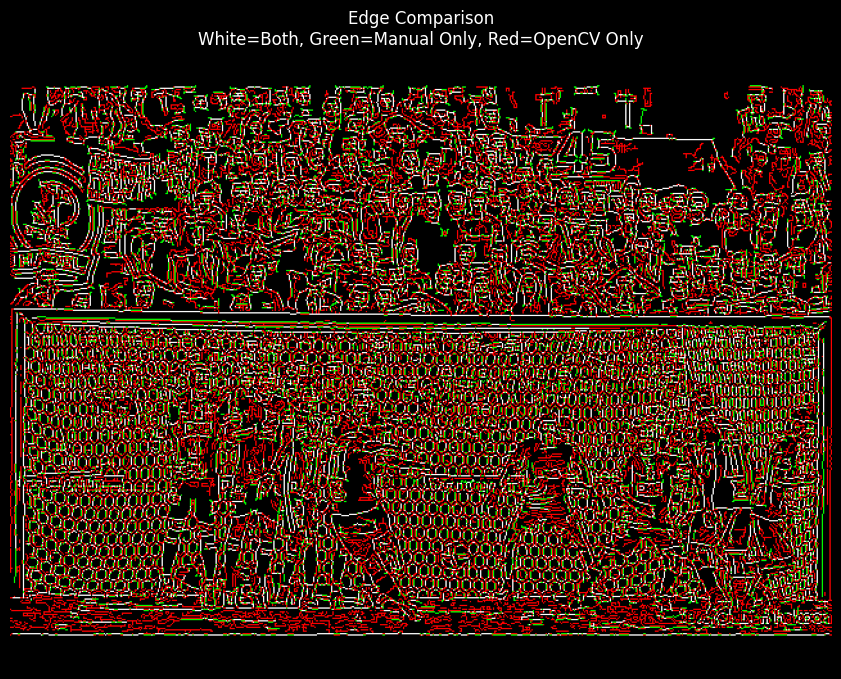

In [11]:
# Visualize differences
manual_binary = (manual_canny_result > 0).astype(np.uint8)
opencv_binary = (opencv_canny > 0).astype(np.uint8)

# Create difference visualization
diff_vis = np.zeros((*manual_binary.shape, 3), dtype=np.uint8)
diff_vis[np.logical_and(manual_binary, opencv_binary)] = [255, 255, 255]  # Both: white
diff_vis[np.logical_and(manual_binary, ~opencv_binary.astype(bool))] = [0, 255, 0]  # Manual only: green
diff_vis[np.logical_and(~manual_binary.astype(bool), opencv_binary)] = [255, 0, 0]  # OpenCV only: red

plt.figure(figsize=(12, 8))
plt.imshow(diff_vis)
plt.title('Edge Comparison\nWhite=Both, Green=Manual Only, Red=OpenCV Only')
plt.axis('off')
plt.show()

---
## Explanation of Differences

The differences between our manual Canny implementation and OpenCV's `cv2.Canny` can be attributed to several factors:

### 1. Gaussian Smoothing
- **OpenCV**: Uses a 5x5 Gaussian filter with a specific sigma value internally (approximately 1.4)
- **Our implementation**: We used a 5x5 Gaussian with sigma=1.4, which should be similar
- **Impact**: Slightly different smoothing can lead to different gradient values and thus different edge positions

### 2. Threshold Settings
- **OpenCV**: Uses absolute threshold values (we used 50 and 150)
- **Our implementation**: Uses ratio-based thresholds relative to the maximum gradient value
- **Impact**: This is likely the biggest source of difference. Different thresholds directly affect which edges are detected

### 3. Numerical Precision
- **OpenCV**: Highly optimized with careful handling of floating-point operations
- **Our implementation**: Uses Python/NumPy which may have slight differences in rounding
- **Impact**: Minor differences in gradient computations can propagate through the pipeline

### 4. Implementation Details
- **NMS interpolation**: OpenCV may use bilinear interpolation for sub-pixel accuracy when comparing neighbors along the gradient direction. Our implementation uses the nearest pixel.
- **Hysteresis algorithm**: OpenCV uses an optimized implementation that may process pixels in a different order
- **Border handling**: Different handling of image borders during convolution can affect edge pixels

### 5. Sobel Kernel
- **OpenCV**: May use slightly different Sobel kernels or normalized versions
- **Our implementation**: Uses the standard 3x3 Sobel kernels

Despite these differences, both implementations successfully detect the main edges in the image, demonstrating that our manual implementation correctly follows the Canny edge detection algorithm.

---
## Complete Pipeline Summary

Below is a visualization of all steps in the Canny edge detection pipeline:

In [ ]:
# Complete pipeline visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Step 0: Original
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Step 0: Original Image')
axes[0, 0].axis('off')

# Step 1: Gaussian Blur
axes[0, 1].imshow(blurred_image, cmap='gray')
axes[0, 1].set_title('Step 1: Gaussian Blur')
axes[0, 1].axis('off')

# Step 2: Gradient Magnitude
axes[0, 2].imshow(grad_magnitude, cmap='gray')
axes[0, 2].set_title('Step 2: Gradient Magnitude')
axes[0, 2].axis('off')

# Step 3: NMS
axes[1, 0].imshow(nms_result, cmap='gray')
axes[1, 0].set_title('Step 3: Non-Maximum Suppression')
axes[1, 0].axis('off')

# Step 4: Double Thresholding
thresh_vis = np.zeros((*thresholded_result.shape, 3), dtype=np.uint8)
thresh_vis[thresholded_result == STRONG] = [255, 255, 255]
thresh_vis[thresholded_result == WEAK] = [128, 128, 128]
axes[1, 1].imshow(thresh_vis)
axes[1, 1].set_title('Step 4: Double Thresholding')
axes[1, 1].axis('off')

# Step 5: Final Result
axes[1, 2].imshow(final_edges, cmap='gray')
axes[1, 2].set_title('Step 5: Final Edges (Hysteresis)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()